#### Getting Data from the Feature Store

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src.hopsworks_setup import read_all_features

df = read_all_features()
df = df.sort_values("time").reset_index(drop=True)
print(df.shape)

ModuleNotFoundError: No module named 'src'

#### 1- Trying to see the long term AQI Trend 

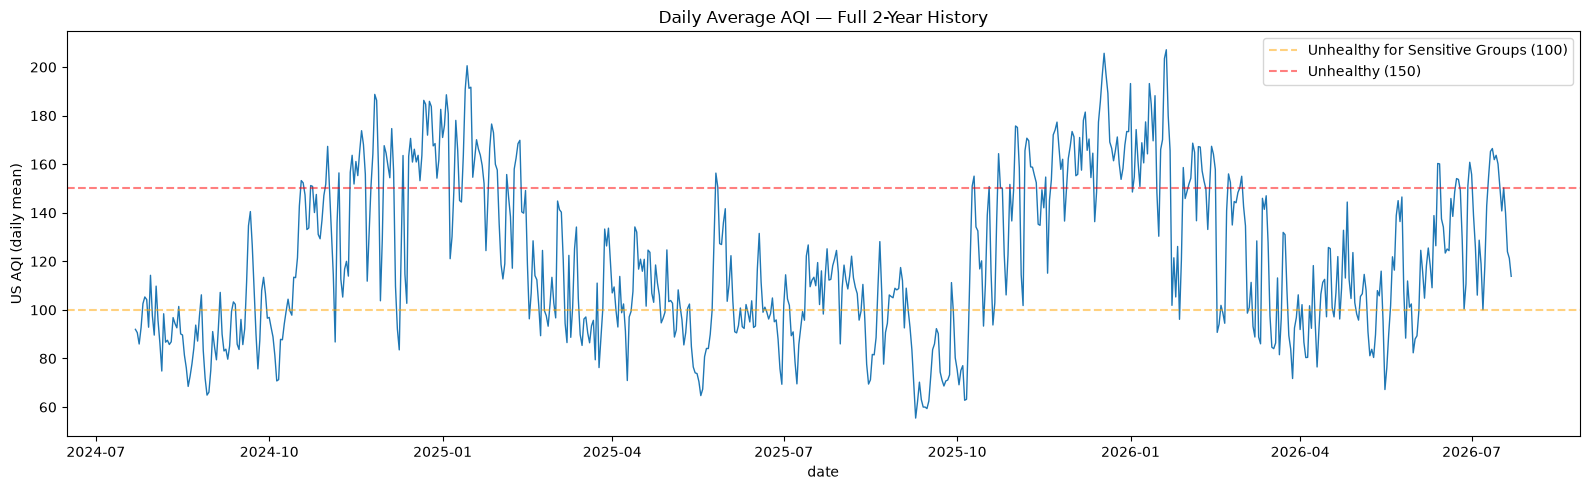

In [2]:
def plot_long_term_trend(df):
    df = df.copy()
    df["date"] = df["time"].dt.date

    daily_avg = df.groupby("date")["us_aqi"].mean().reset_index()
    daily_avg["date"] = pd.to_datetime(daily_avg["date"])

    plt.figure(figsize=(16, 5))
    plt.plot(daily_avg["date"], daily_avg["us_aqi"], linewidth=1)
    plt.axhline(y=100, color="orange", linestyle="--", alpha=0.5, label="Unhealthy for Sensitive Groups (100)")
    plt.axhline(y=150, color="red", linestyle="--", alpha=0.5, label="Unhealthy (150)")
    plt.title("Daily Average AQI — Full 2-Year History")
    plt.xlabel("date")
    plt.ylabel("US AQI (daily mean)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_long_term_trend(df)

#### 2- Finding Hour-of-Day Pattern

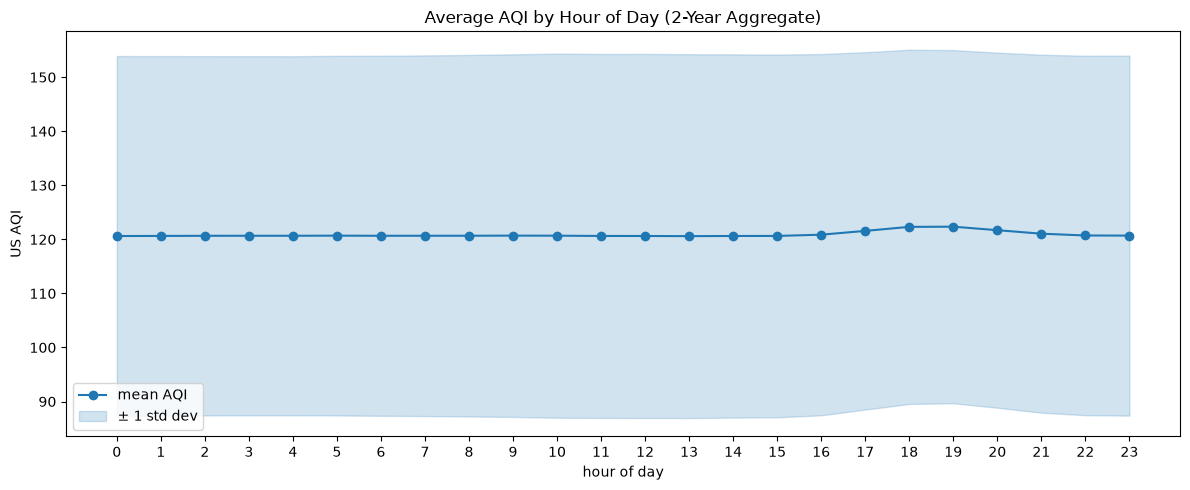

In [8]:
def plot_hourly_pattern(df):
    plt.figure(figsize=(12, 5))

    hourly_stats = df.groupby("hour")["us_aqi"].agg(["mean", "std"]).reset_index()

    plt.plot(hourly_stats["hour"], hourly_stats["mean"], marker="o", color="tab:blue", label="mean AQI")
    plt.fill_between(
        hourly_stats["hour"],
        hourly_stats["mean"] - hourly_stats["std"],
        hourly_stats["mean"] + hourly_stats["std"],
        alpha=0.2, color="tab:blue", label="± 1 std dev"
    )

    plt.xticks(range(0, 24))
    plt.xlabel("hour of day")
    plt.ylabel("US AQI")
    plt.title("Average AQI by Hour of Day (2-Year Aggregate)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hourly_pattern(df)

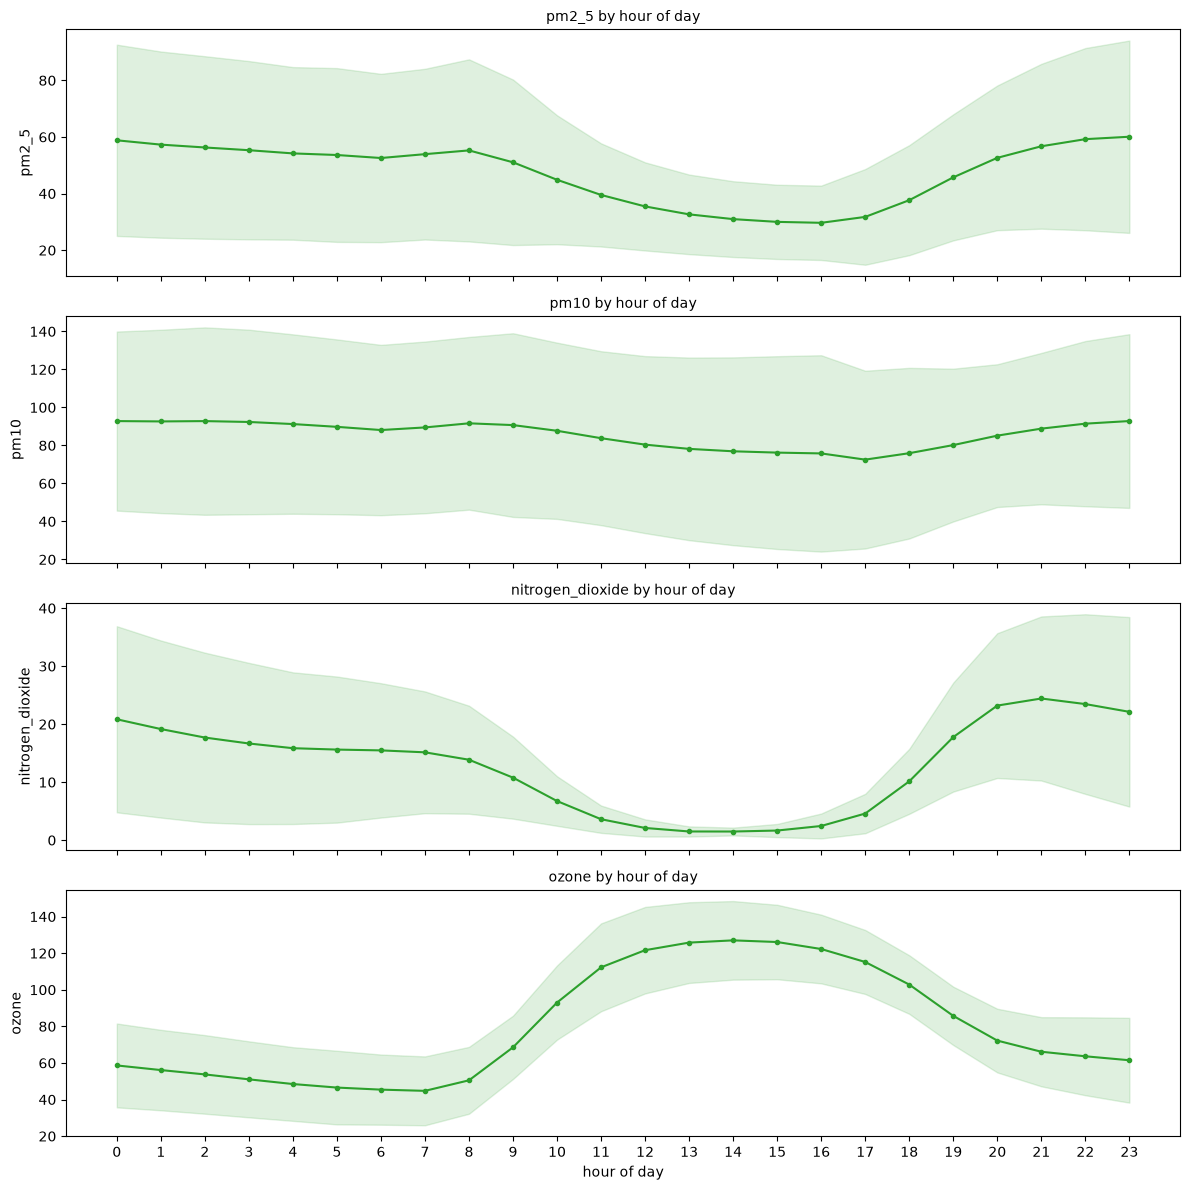

In [9]:
def plot_hourly_pollutants(df, pollutants=["pm2_5", "pm10", "nitrogen_dioxide", "ozone"]):
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(12, 3 * len(pollutants)), sharex=True)

    for ax, pollutant in zip(axes, pollutants):
        hourly_stats = df.groupby("hour")[pollutant].agg(["mean", "std"]).reset_index()

        ax.plot(hourly_stats["hour"], hourly_stats["mean"], marker="o", markersize=3, color="tab:green")
        ax.fill_between(
            hourly_stats["hour"],
            hourly_stats["mean"] - hourly_stats["std"],
            hourly_stats["mean"] + hourly_stats["std"],
            alpha=0.15, color="tab:green"
        )
        ax.set_ylabel(pollutant)
        ax.set_title(f"{pollutant} by hour of day", fontsize=10)

    axes[-1].set_xlabel("hour of day")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

plot_hourly_pollutants(df)

#### 3- Finding Day-of-Week Pattern

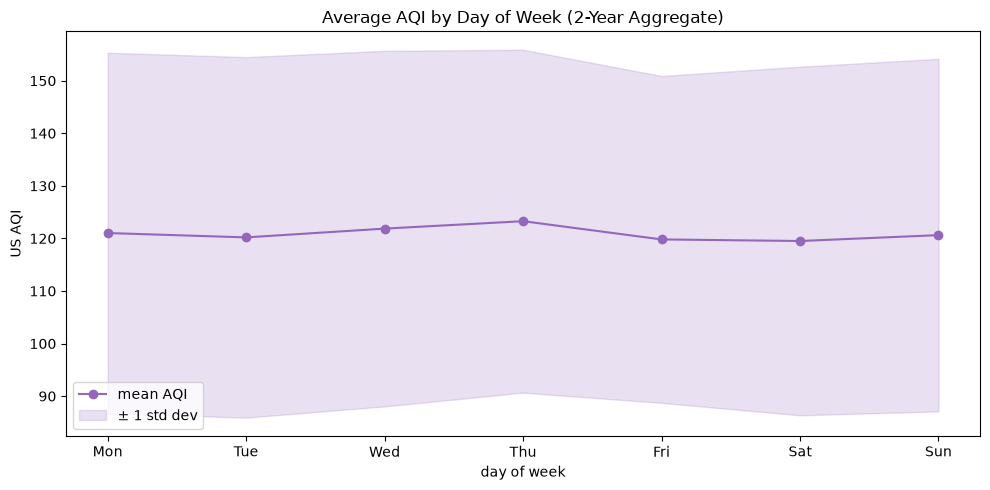

In [6]:
def plot_day_of_week_pattern(df):
    plt.figure(figsize=(10, 5))

    dow_stats = df.groupby("day_of_week")["us_aqi"].agg(["mean", "std"]).reset_index()
    dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    plt.plot(dow_stats["day_of_week"], dow_stats["mean"], marker="o", color="tab:purple", label="mean AQI")

    plt.fill_between(
        dow_stats["day_of_week"],
        dow_stats["mean"] - dow_stats["std"],
        dow_stats["mean"] + dow_stats["std"],
        alpha=0.2, color="tab:purple", label="± 1 std dev"
    )

    plt.xticks(range(7), dow_labels)
    plt.xlabel("day of week")
    plt.ylabel("US AQI")
    plt.title("Average AQI by Day of Week (2-Year Aggregate)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_day_of_week_pattern(df)

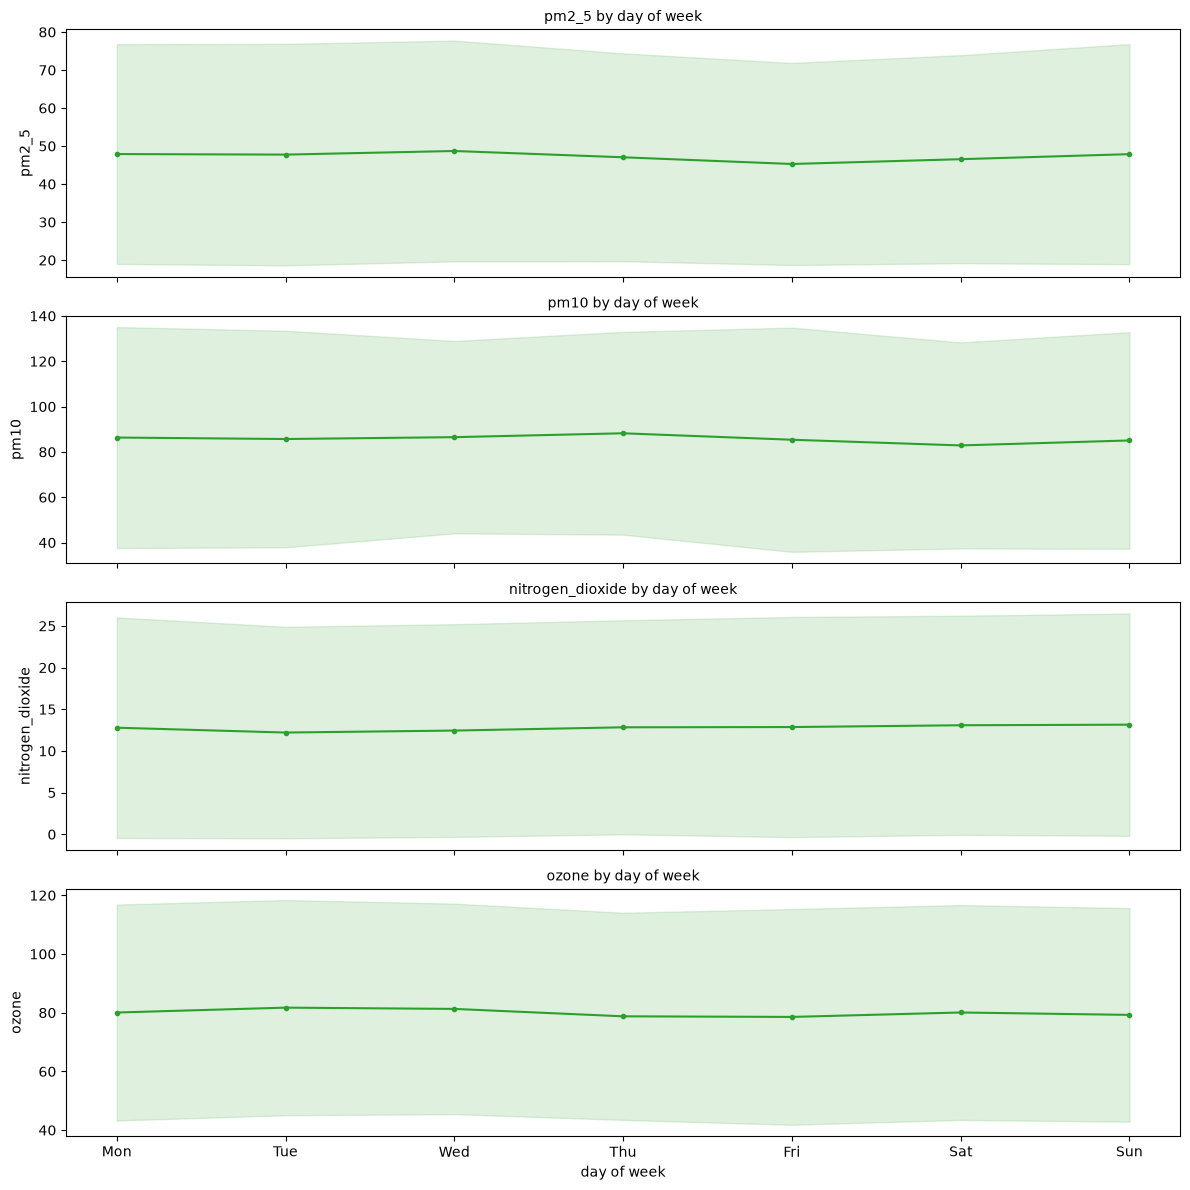

In [3]:

def plot_weekly_pollutants(df, pollutants=["pm2_5", "pm10", "nitrogen_dioxide", "ozone"]):
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(12, 3 * len(pollutants)), sharex=True)

    for ax, pollutant in zip(axes, pollutants):
        hourly_stats = df.groupby("day_of_week")[pollutant].agg(["mean", "std"]).reset_index()

        ax.plot(hourly_stats["day_of_week"], hourly_stats["mean"], marker="o", markersize=3, color="tab:green")
        ax.fill_between(
            hourly_stats["day_of_week"],
            hourly_stats["mean"] - hourly_stats["std"],
            hourly_stats["mean"] + hourly_stats["std"],
            alpha=0.15, color="tab:green"
        )
        ax.set_ylabel(pollutant)
        ax.set_title(f"{pollutant} by day of week", fontsize=10)

    axes[-1].set_xlabel("day of week")
    plt.xticks(range(0, 7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    plt.tight_layout()
    plt.show()

plot_weekly_pollutants(df)

#### 4- Correlation Matrix

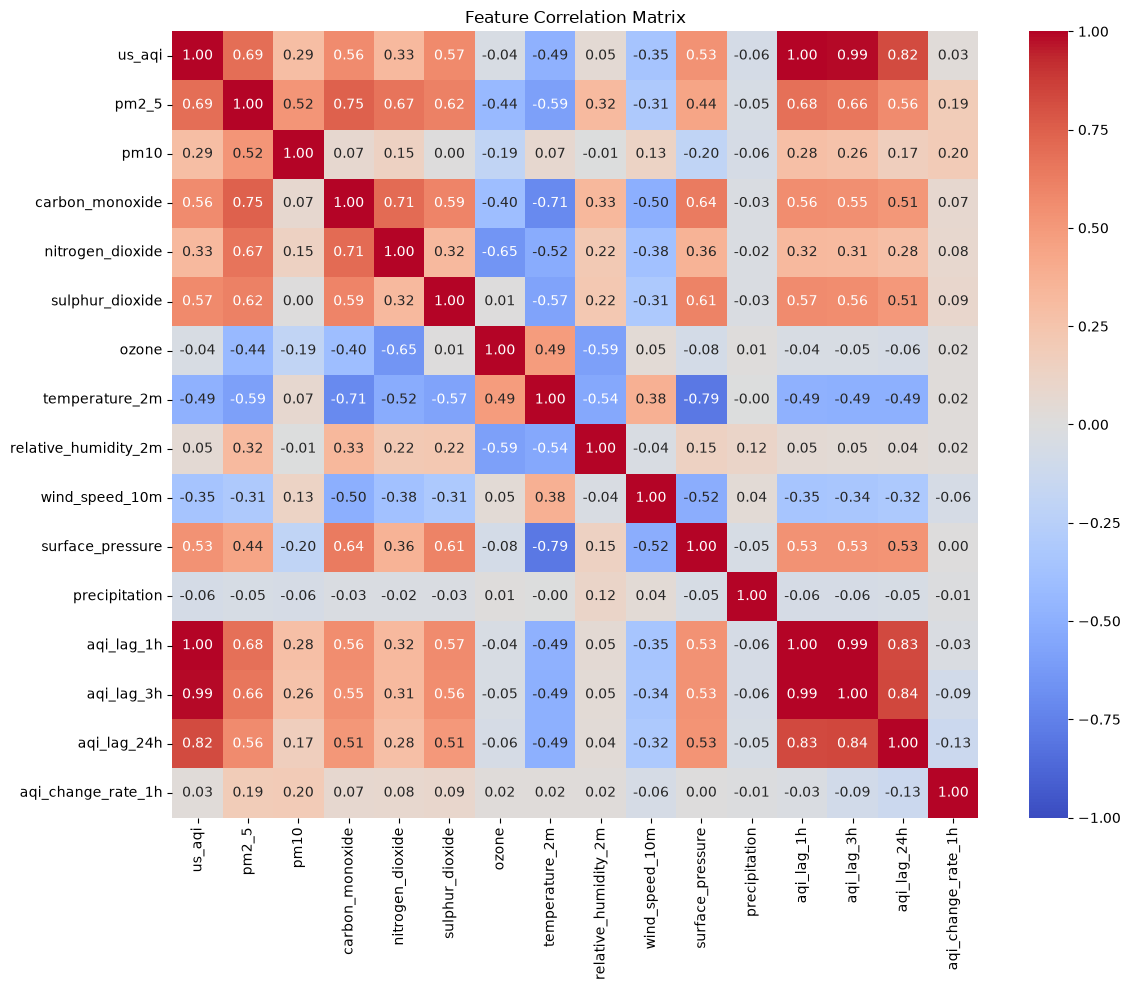

us_aqi                  1.000000
aqi_lag_1h              0.998399
aqi_lag_3h              0.989324
aqi_lag_24h             0.821326
pm2_5                   0.693390
sulphur_dioxide         0.571426
carbon_monoxide         0.563997
surface_pressure        0.533172
nitrogen_dioxide        0.328077
pm10                    0.293060
relative_humidity_2m    0.049593
aqi_change_rate_1h      0.027834
ozone                  -0.043779
precipitation          -0.062945
wind_speed_10m         -0.351624
temperature_2m         -0.490612
Name: us_aqi, dtype: float64


In [6]:
import seaborn as sns

def plot_correlation_matrix(df):
    feature_cols = [
        "us_aqi", "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide",
        "sulphur_dioxide", "ozone", "temperature_2m", "relative_humidity_2m",
        "wind_speed_10m", "surface_pressure", "precipitation",
        "aqi_lag_1h", "aqi_lag_3h", "aqi_lag_24h", "aqi_change_rate_1h"
    ]

    corr = df[feature_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

    return corr

corr = plot_correlation_matrix(df)
print(corr["us_aqi"].sort_values(ascending=False))

#### 5- Missing-Data Check

In [5]:
df1 = pd.read_csv("aqi_features.csv", parse_dates=["time"])
def check_missing_data(df):
    df = df.sort_values("time").reset_index(drop=True)

    # Check for NaNs
    print("Null counts:\n", df.isna().sum()[df.isna().sum() > 0])

    # Check for actual gaps in the hourly time sequence
    expected_range = pd.date_range(start=df["time"].min(), end=df["time"].max(), freq="h")
    missing_hours = expected_range.difference(df["time"])

    print(f"\nExpected hourly timestamps: {len(expected_range)}")
    print(f"Actual timestamps present: {len(df)}")
    print(f"Missing hours: {len(missing_hours)}")
    if len(missing_hours) > 0:
        print(missing_hours[:20])  # preview first 20 gaps

check_missing_data(df1)

Null counts:
 Series([], dtype: int64)

Expected hourly timestamps: 17544
Actual timestamps present: 17544
Missing hours: 0


##### Extra Stuff

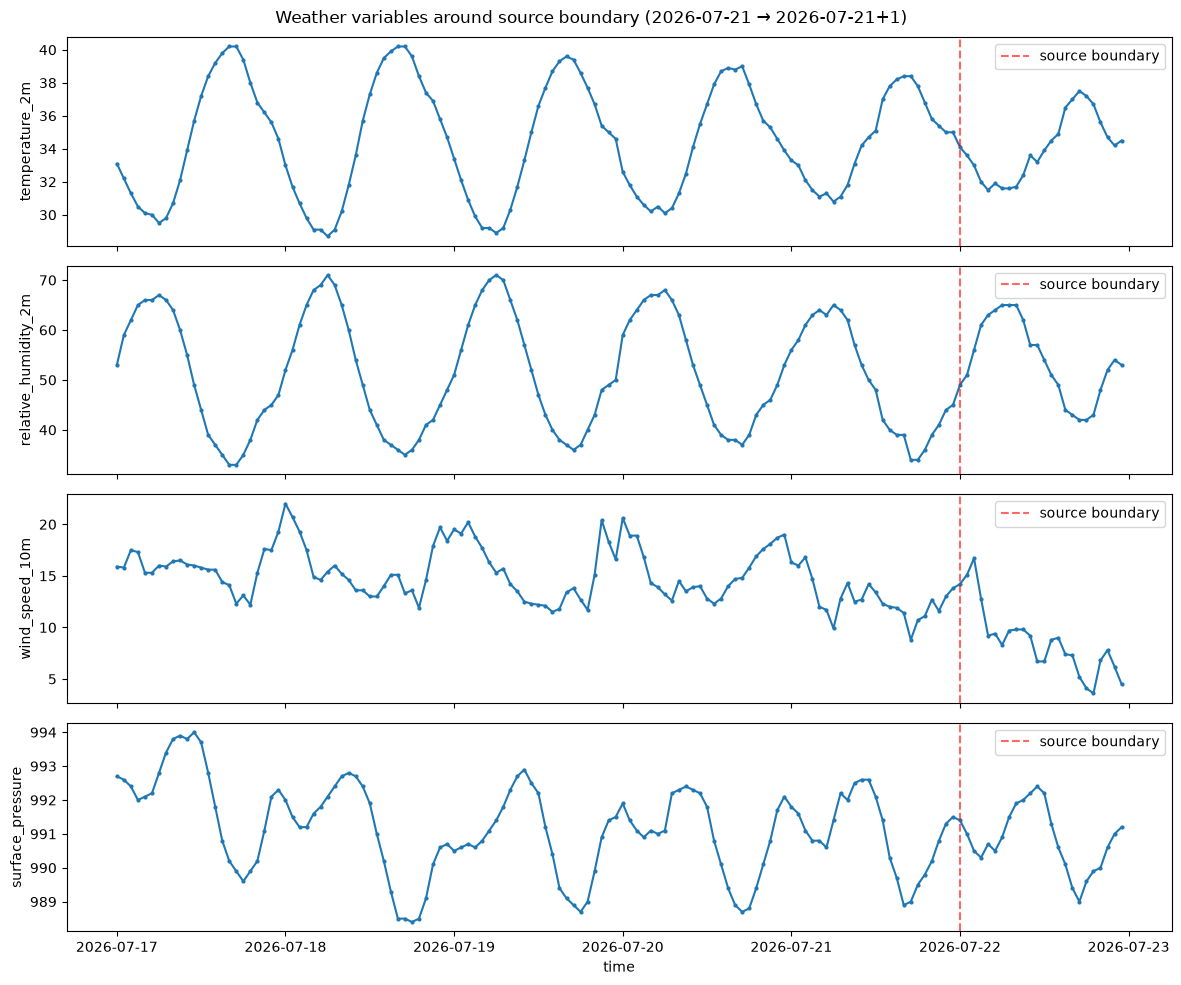

In [2]:

def plot_boundary_check(df, boundary_date="2026-07-21", window_days=4):
    boundary = pd.Timestamp(boundary_date)
    start = boundary - pd.Timedelta(days=window_days)
    end = boundary + pd.Timedelta(days=window_days)

    window_df = df[(df["time"] >= start) & (df["time"] <= end)].copy()

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    variables = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]

    for ax, var in zip(axes, variables):
        ax.plot(window_df["time"], window_df[var], marker="o", markersize=2)
        ax.axvline(boundary + pd.Timedelta(hours=24), color="red", linestyle="--", alpha=0.6, label="source boundary")
        ax.set_ylabel(var)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time")
    plt.suptitle(f"Weather variables around source boundary ({boundary_date} → {boundary_date}+1)")
    plt.tight_layout()
    plt.show()


plot_boundary_check(df)
